# Kendall's Rank Correlation

Compare rankings between two CSV files for a given query using Kendall's Tau.

In [1]:
%pip install -r requirements.txt -q

import pandas as pd
import numpy as np
from scipy.stats import kendalltau
import os

Note: you may need to restart the kernel to use updated packages.


## Configuration

Choose two CSV files and a query to compare.

In [3]:
BASE_DIR = r".\csv"

AVAILABLE_FILES = {
    "brute_force_card_declined": os.path.join(BASE_DIR, "brute_force_results_card_declined.csv"),
    "brute_force_pay_meal": os.path.join(BASE_DIR, "brute_force_results_pay_meal.csv"),
    "semantic_count": os.path.join(BASE_DIR, "semantic_count_results.csv"),
}

print("Available files:")
for name, path in AVAILABLE_FILES.items():
    exists = os.path.exists(path)
    print(f"  {name}: {'OK' if exists else 'MISSING'} - {path}")

Available files:
  brute_force_card_declined: OK - .\csv\brute_force_results_card_declined.csv
  brute_force_pay_meal: OK - .\csv\brute_force_results_pay_meal.csv
  semantic_count: OK - .\csv\semantic_count_results.csv


In [4]:
# ============================================================
# SELECT TWO FILES AND A QUERY HERE
# ============================================================

FILE_A = "brute_force_card_declined"  # change to any key from AVAILABLE_FILES
FILE_B = "semantic_count"             # change to any key from AVAILABLE_FILES

QUERY = "My card declines when I pay for my meal."

# ============================================================

In [5]:
df_a = pd.read_csv(AVAILABLE_FILES[FILE_A])
df_b = pd.read_csv(AVAILABLE_FILES[FILE_B])

queries_a = set(df_a["query"].dropna().unique())
queries_b = set(df_b["query"].dropna().unique())
common_queries = sorted(queries_a & queries_b)

print(f"Queries in {FILE_A}: {sorted(queries_a)}")
print(f"Queries in {FILE_B}: {sorted(queries_b)}")
print(f"\nCommon queries: {common_queries}")

if QUERY not in common_queries:
    print(f"\nWARNING: '{QUERY}' is not present in both files!")
    print("Pick one of the common queries above.")
else:
    print(f"\nSelected query is valid: '{QUERY}'")

Queries in brute_force_card_declined: ['My card declines when I pay for my meal.']
Queries in semantic_count: ['I dropped my credit card in the river.', 'My card declines when I pay for my meal.']

Common queries: ['My card declines when I pay for my meal.']

Selected query is valid: 'My card declines when I pay for my meal.'


## Compute Kendall's Tau

We join the two result sets on `sentence`, then compute the correlation between their rank orderings.

In [6]:
ranks_a = df_a[df_a["query"] == QUERY][["sentence", "rank"]].rename(columns={"rank": "rank_a"})
ranks_b = df_b[df_b["query"] == QUERY][["sentence", "rank"]].rename(columns={"rank": "rank_b"})

merged = ranks_a.merge(ranks_b, on="sentence", how="inner")

print(f"Sentences in {FILE_A}: {len(ranks_a)}")
print(f"Sentences in {FILE_B}: {len(ranks_b)}")
print(f"Common sentences (inner join): {len(merged)}")
print(f"\nFirst 10 rows of merged rankings:")
merged.head(10)

Sentences in brute_force_card_declined: 409
Sentences in semantic_count: 185
Common sentences (inner join): 89

First 10 rows of merged rankings:


,sentence,rank_a,rank_b
0,"I made a card payment, but it has been declined?",1.0,23
1,Today I used my card at a restaurant and it wa...,13.0,1
2,Why did my payment get declined?,20.0,2
3,Why has my card been declined?,22.0,4
4,Why are all my card payments being declined?,28.0,7
5,Why has my payment been declined? I paid by card.,30.0,8
6,My payment card was declined - could you tell ...,36.0,10
7,Why was my payment declined? I keep trying my ...,40.0,11
8,My card was declined,41.0,12
9,My credit card has been declined.,44.0,14


In [7]:
if len(merged) < 2:
    print("Not enough common sentences to compute Kendall's Tau.")
else:
    tau, p_value = kendalltau(merged["rank_a"], merged["rank_b"])
    print(f"Query: {QUERY}")
    print(f"File A: {FILE_A}")
    print(f"File B: {FILE_B}")
    print(f"Common sentences: {len(merged)}")
    print(f"\nKendall's Tau: {tau:.4f}")
    print(f"P-value:        {p_value:.4e}")
    print(f"\nInterpretation:")
    if abs(tau) < 0.1:
        print("  Very weak or no correlation between the two rankings.")
    elif abs(tau) < 0.3:
        print("  Weak correlation between the two rankings.")
    elif abs(tau) < 0.5:
        print("  Moderate correlation between the two rankings.")
    elif abs(tau) < 0.7:
        print("  Strong correlation between the two rankings.")
    else:
        print("  Very strong correlation between the two rankings.")

Query: My card declines when I pay for my meal.
File A: brute_force_card_declined
File B: semantic_count
Common sentences: 89

Kendall's Tau: 0.6752
P-value:        7.2588e-21

Interpretation:
  Strong correlation between the two rankings.


## Visualization

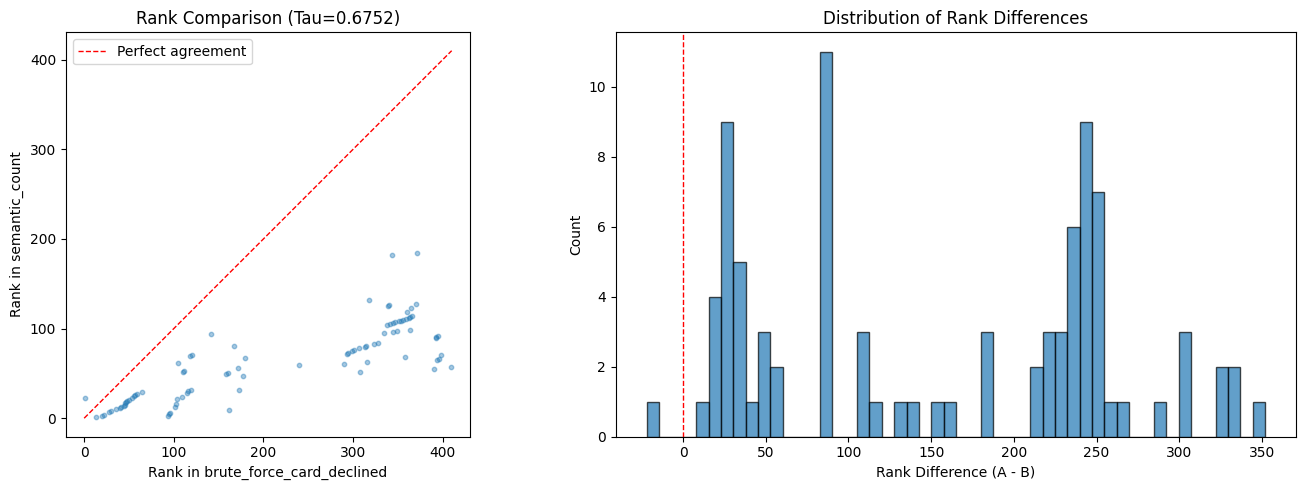

In [8]:
import matplotlib.pyplot as plt

if len(merged) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(merged["rank_a"], merged["rank_b"], alpha=0.4, s=10)
    lims = [0, max(merged["rank_a"].max(), merged["rank_b"].max()) + 1]
    axes[0].plot(lims, lims, "r--", linewidth=1, label="Perfect agreement")
    axes[0].set_xlabel(f"Rank in {FILE_A}")
    axes[0].set_ylabel(f"Rank in {FILE_B}")
    axes[0].set_title(f"Rank Comparison (Tau={tau:.4f})")
    axes[0].legend()
    axes[0].set_aspect("equal", adjustable="box")

    diff = merged["rank_a"] - merged["rank_b"]
    axes[1].hist(diff, bins=50, edgecolor="black", alpha=0.7)
    axes[1].axvline(0, color="r", linestyle="--", linewidth=1)
    axes[1].set_xlabel("Rank Difference (A - B)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Distribution of Rank Differences")

    plt.tight_layout()
    plt.show()

## Batch: All Queries Across Two Files

Compute Kendall's Tau for every common query between the two selected files.

In [9]:
results = []
for q in common_queries:
    ra = df_a[df_a["query"] == q][["sentence", "rank"]].rename(columns={"rank": "rank_a"})
    rb = df_b[df_b["query"] == q][["sentence", "rank"]].rename(columns={"rank": "rank_b"})
    m = ra.merge(rb, on="sentence", how="inner")
    if len(m) >= 2:
        t, p = kendalltau(m["rank_a"], m["rank_b"])
        results.append({"query": q, "common_sentences": len(m), "kendall_tau": t, "p_value": p})

if results:
    results_df = pd.DataFrame(results)
    display(results_df)
else:
    print("No common queries with enough shared sentences.")

,query,common_sentences,kendall_tau,p_value
0,My card declines when I pay for my meal.,89,0.675179,7.258847e-21
